In [10]:
import requests
from io import BytesIO
import pandas as pd

# Se descargan los presupuestos de la página del ministerio de Hacienda

url = "https://www.sepg.pap.hacienda.gob.es/sitios/sepg/es-ES/Presupuestos/DocumentacionEstadisticas/Estadisticas/Documents/2025-P/01%20Presupuestos%20Generales%20del%20Estado%20Consolidados.xlsx"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0 Safari/537.36"
}

r = requests.get(url, headers=headers)

# Se lee el archivo

excel_bytes = BytesIO(r.content)

In [11]:
import pandas as pd

# Se separan los datos de ingresos y gastos

gastos = pd.read_excel(excel_bytes, sheet_name = 1)
ingresos = pd.read_excel(excel_bytes, sheet_name = 7)

# Se seleccionan las filas relevantes debido al formato del archivo

filas_relevantes_gastos = [5, 6, 7, 8, 10, 11, 12, 15, 16]
filas_relevantes_ingresos = [5, 6, 7, 8, 9, 11, 12, 15]

gastos_filtrado = gastos.iloc[filas_relevantes_gastos, [0, 10]].reset_index(drop=True)
ingresos_filtrado = ingresos.iloc[filas_relevantes_ingresos, [0, 10]].reset_index(drop=True)

# Renombro las columnas

gastos_filtrado.columns = ["Partida", "Cantidad"]
ingresos_filtrado.columns = ["Partida", "Cantidad"]

# Ya que hay algunos conceptos que gastos y en ingresos son iguales, se utilizará el prefijo "1." para los ingresos
# y el "2." para los gastos

ingresos_filtrado.iloc[:, 0] = "1. " + ingresos_filtrado.iloc[:, 0]
gastos_filtrado.iloc[:, 0] = "2. " + gastos_filtrado.iloc[:, 0]

# Credo un diccionario con los índices de los ingresos, el estado (que será el intermediario) y los gastos. Esto servirá para determinar
# los orígenes y destinos de los flujos

indices_ingresos = {ingresos_filtrado.iloc[i,0]: i for i in range(ingresos_filtrado.shape[0])}
indice_estado = {"Estado": len(indices_ingresos)}
indices_gastos = {gastos_filtrado.iloc[i,0]: i + len(indices_ingresos) + 1 for i in range(gastos_filtrado.shape[0])}

# Las fuentes de flujos relativos a ingresos serán los índices de cada uno de los ingresos. El destino será el Estado para todos 
# y los valores la cuantía de cada ingreso

sources_ingresos = [x for x in indices_ingresos.values()]
targets_ingresos = len(sources_ingresos) * [indice_estado["Estado"]]
values_ingresos = [x for x in ingresos_filtrado.iloc[:, 1]]

# Para los gastos, la fuente será siempre el índice del estado, los índices de cada partida de gasto y el valor la cuantía.

targets_gastos = [x for x in indices_gastos.values()]
sources_gastos = len(targets_gastos) * [indice_estado["Estado"]]
values_gastos = [x for x in gastos_filtrado.iloc[:, 1]]

# Unifico todas las fuentes, destinos y gastos

sources_totales = sources_ingresos + sources_gastos
targets_totales = targets_ingresos + targets_gastos
values_totales = values_ingresos + values_gastos

In [12]:
import plotly.graph_objects as go

# Para la etiqueta de cada flujo utilizo los diccionarios de ingresos y gastos creados antes

labels = [x for x in indices_ingresos.keys()] + ["Estado"] + [x for x in indices_gastos.keys()]

# Se crea la figura

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
        hovertemplate='Nodo: %{label}<extra>%{value}</extra>'
    ),
    link=dict(
        source=sources_totales,
        target=targets_totales,
        value=values_totales,
        hovertemplate='Source: %{source.label}<br>Target: %{target.label}<extra>%{value}</extra>'
    )
)])

# Se agrega un título y una leyenda

fig.update_layout(title=dict(text = "Flujos de Ingresos → Estado → Gastos 2025", x=0.5, xanchor='center'), annotations=[
        dict(
            x=0,
            y=1.1,
            text="<br>1. = Impuestos<br>2. = Gastos",
            align="left",
            showarrow=False,
            bordercolor="black"
        )
    ])

In [13]:
# Ya que plotly no muestra automáticamente el resultado de ejecución en GitHub, se guarda la figura en una imagen

fig.write_image("Sankey.png", width=1000, height=500, scale=2)

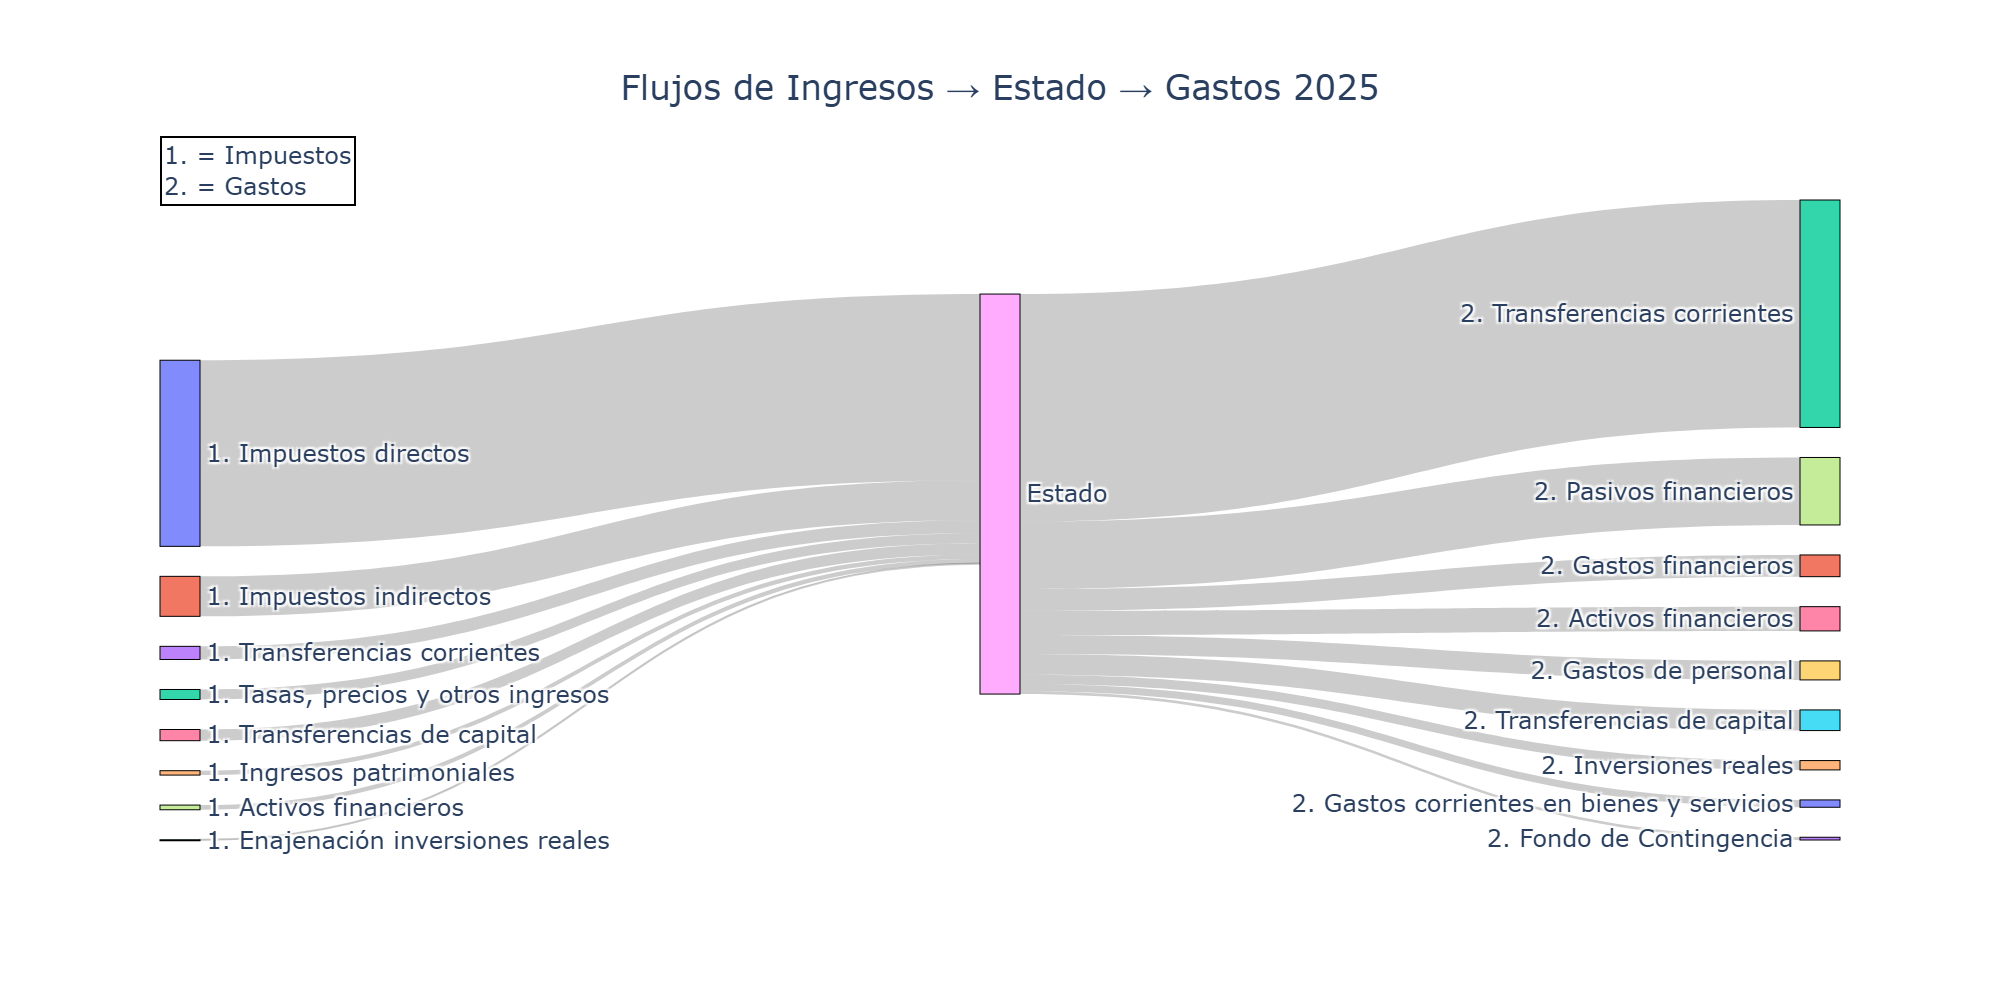

In [14]:
from IPython.display import Image

# Se muestra la imagen
Image("Sankey.png")